## PtyChee Iterative Ptychogrpahy with Scanning Position Correction Demo

Running position correction in ePIE and LSQML ptychography

Author: Zeyu Wang <br>
October 2026

In [1]:
import numpy as np
from PtyChee import run

4D-STEM data and parameters read in.<br>
Data from https://doi.org/10.1038/s41467-020-16688-6 can be downloaded from https://data.paradim.org/doi/g4wa-0j57/.

In [2]:
import scipy.io

folder_path = 'data/'
file = 'rawdata_1x_crop'
data = scipy.io.loadmat(folder_path+file+'.mat')
data_4D = np.transpose(data['cbed'], (2, 3, 0, 1))
print(data_4D.shape)

Voltage = data['voltage'].item()                # keV, accelerate votage
alpha = data['alpha0'].item()/1000              # rad, semi convergence angle
scan_step = data['scanstep'].item()             # Å,   scan step size

defocus = -data['df'].item()                    # Å,   defocus
scan_rotation_angle = -data['rot_ang'].item()   # degree
scan_flip = False                               # flip X axis or not

print('scan step: '+str(scan_step)+' Å')
print('scan rotation angle: '+str(scan_rotation_angle)+' degree')

(60, 60, 124, 124)
scan step: 0.85 Å
scan rotation angle: 30 degree


We use the parameters in the .mat file to reconstruct the data without scanning position correction to see what happens.


ePIE

File: rawdata_1x_crop

################ Experimental Information ################
Voltage: 80 kV
Alpha: 0.0214 rad
scan step: 0.85 Å/pixel
defocus: 500 Å
scan rotation angle: 30 degrees
scan flip x: False

#################### Data Information ####################
data shape: (60, 60, 124, 124)
data type: float32
CBED intensity range: -36.02002716064453 – 12631.6630859375
average CBED intensity: 13343601.0
BF center_Y: 61.8842476094615
BF center_X: 62.277805737292404
BF threshold: 0.5
Aperture Radius: 25.123368670217836 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.020398809585216355 1/Å/pixel
real space pixel size: 0.3953424877732503 Å/pixel
ptycho move: 2.1500345302818036 pixels

############### Probe Mixstates Parameters ###############
Probe States: 3
Probe Generation Mode: Hermite
Probe Radius: 28.42534080710379 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 1
recovered objFunc shape: (1,

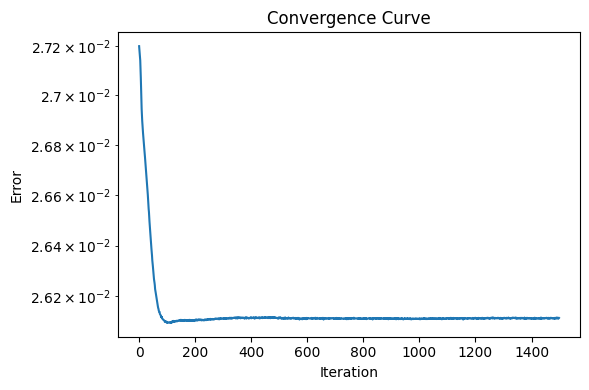

Object saving


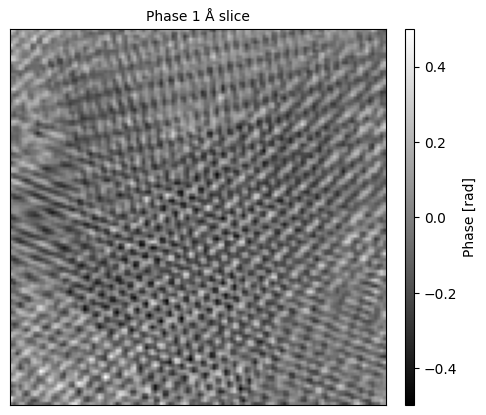

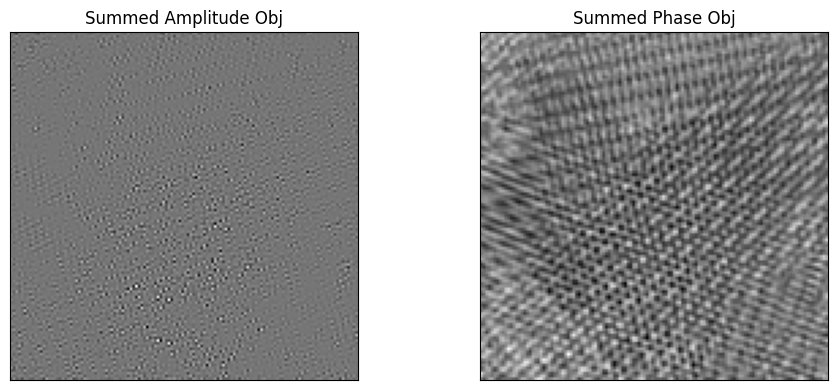

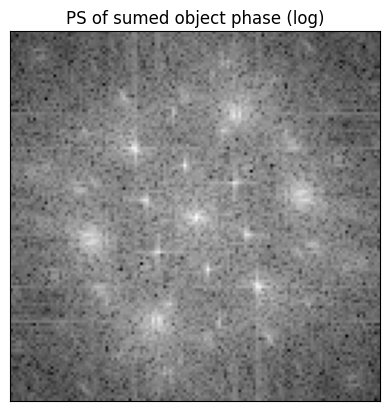

In [ ]:
# ePIE
run.run_ePIE(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 3,                   # probe states number
        n_slice = 1,                   # object slices number
        slice_thickness = 1,           # object slice thickness in Å
        iter_max = 1500,               # maximum iteration numner
        s_O = 1,                       # step size for updating Object Function
        s_P = 1,                       # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing    

        POA = True,                    # phase object approximation constraint
        # device = "cuda:0",           # specify the GPU device or use "cpu"
        
        plot_and_save_probe = False,   # set 'True' to plot and save the probe results
        save_results = False,          # set 'True' to save the results
)

The reconstruction fails. Let's turn on position correction:


ePIE

File: rawdata_1x_crop

################ Experimental Information ################
Voltage: 80 kV
Alpha: 0.0214 rad
scan step: 0.85 Å/pixel
defocus: 500 Å
scan rotation angle: 30 degrees
scan flip x: False

#################### Data Information ####################
data shape: (60, 60, 124, 124)
data type: float32
CBED intensity range: 0.0 – 12631.6630859375
average CBED intensity: 13356662.0
BF center_Y: 61.8842476094615
BF center_X: 62.277805737292404
BF threshold: 0.5
Aperture Radius: 25.123368670217836 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.020398809585216355 1/Å/pixel
real space pixel size: 0.3953424877732503 Å/pixel
ptycho move: 2.1500345302818036 pixels

############### Probe Mixstates Parameters ###############
Probe States: 3
Probe Generation Mode: Hermite
Probe Radius: 28.442925306655784 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 1
recovered objFunc shape: (1, 338, 338)
Sli

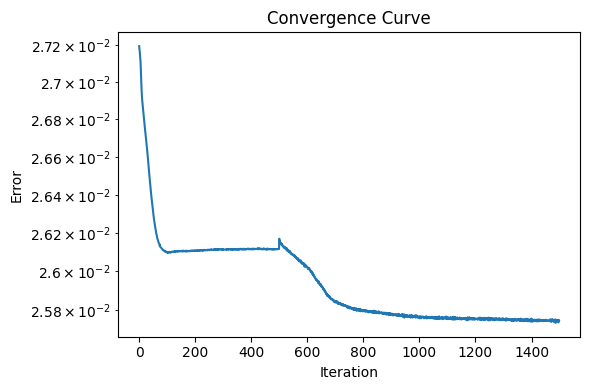

Object saving


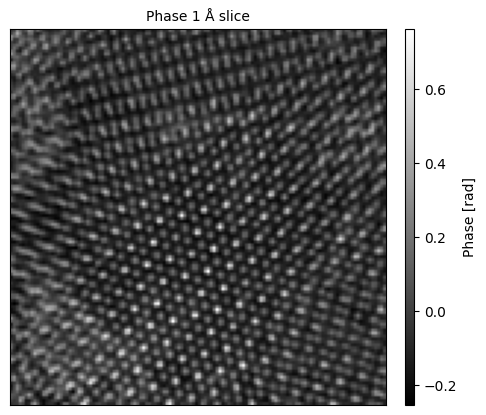

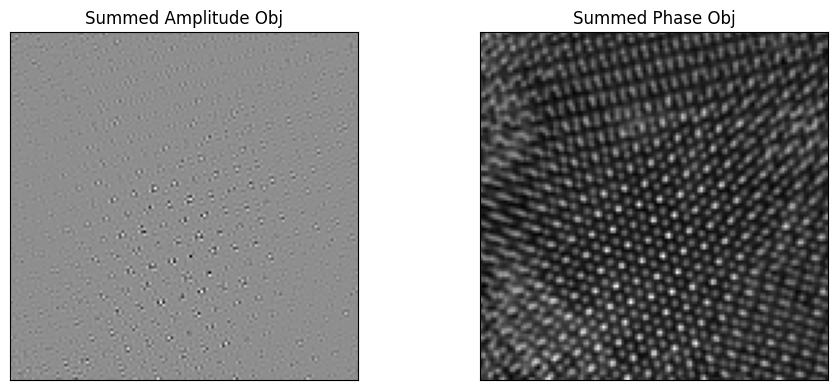

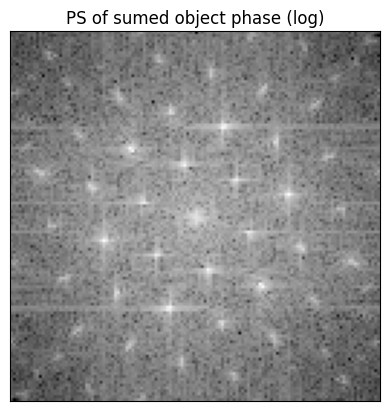

PC saving


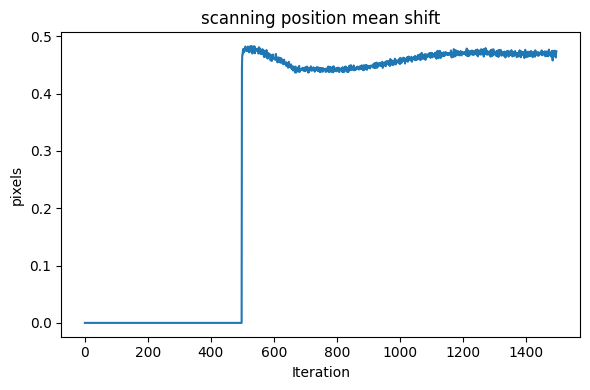

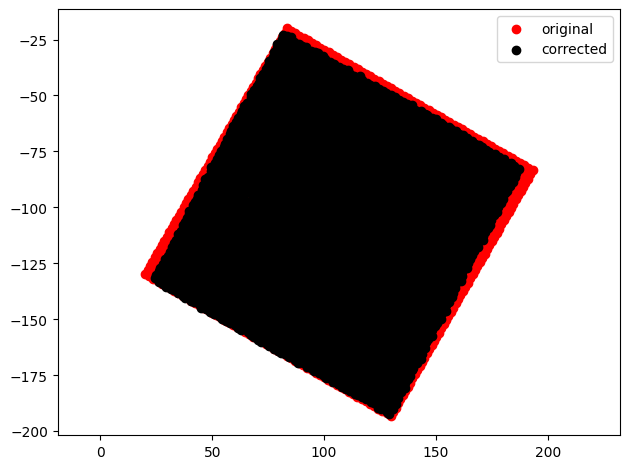

In [ ]:
# ePIE
run.run_ePIE(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 3,                   # probe states number
        n_slice = 1,                   # object slices number
        slice_thickness = 1,           # object slice thickness in Å
        iter_max = 1500,               # maximum iteration numner
        s_O = 1,                       # step size for updating Object Function
        s_P = 1,                       # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing    
        
        s_position_correction = 1,     # step of position correction
        pc_start_iteration = 500,      # if not setting, position correction will start after 0.25*iter_max
        Obj_pad = 20,                  # pixels, padding the objFunc in case scan positions shift out
        
        POA = True,                    # phase object approximation constraint
        # device = "cuda:0",           # specify the GPU device or use "cpu"
        
        plot_and_save_probe = False,   # set 'True' to plot and save the probe results
        save_results = False,          # set 'True' to save the results
)

It works! From the refined scanning positions, we can see that the actual rotation angle is around 28°.

We can try more inaccurate initial parameters to check whether the position correction still works, such as increasing the scan step size from 0.85 Å to 0.9 Å and using a rotation angle of 23° instead of 28°.


ePIE

File: rawdata_1x_crop

################ Experimental Information ################
Voltage: 80 kV
Alpha: 0.0214 rad
scan step: 0.9 Å/pixel
defocus: 500 Å
scan rotation angle: 23 degrees
scan flip x: False

#################### Data Information ####################
data shape: (60, 60, 124, 124)
data type: float32
CBED intensity range: 0.0 – 12631.6630859375
average CBED intensity: 13356662.0
BF center_Y: 61.8842476094615
BF center_X: 62.277805737292404
BF threshold: 0.5
Aperture Radius: 25.123368670217836 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.020398809585216355 1/Å/pixel
real space pixel size: 0.3953424877732503 Å/pixel
ptycho move: 2.2765071497101452 pixels

############### Probe Mixstates Parameters ###############
Probe States: 3
Probe Generation Mode: Hermite
Probe Radius: 28.442925306655784 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 1
recovered objFunc shape: (1, 341, 341)
Slic

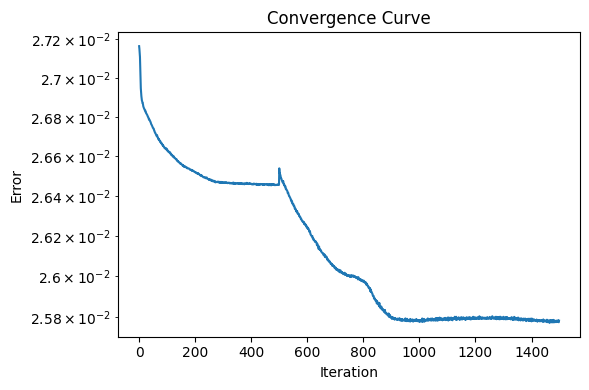

Object saving


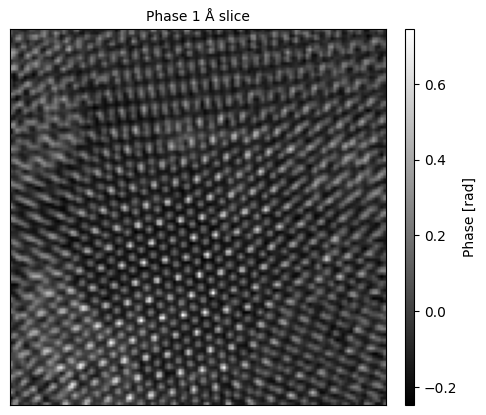

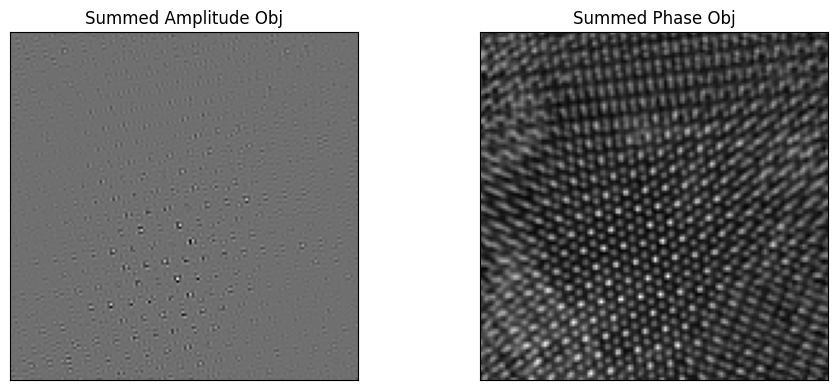

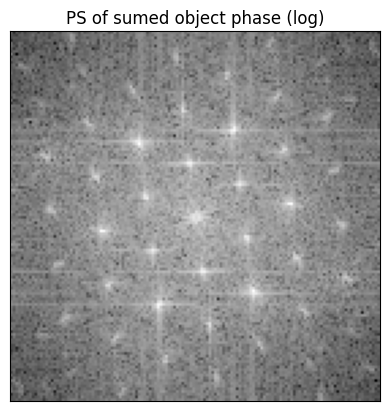

PC saving


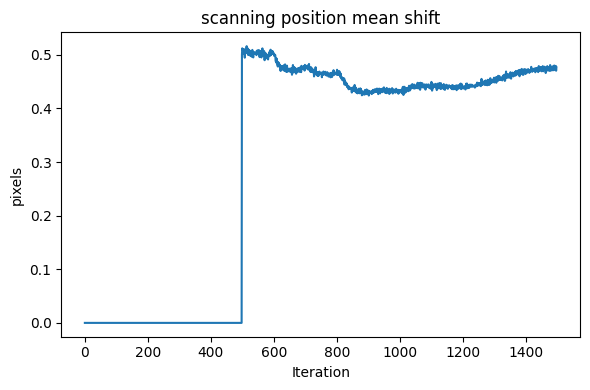

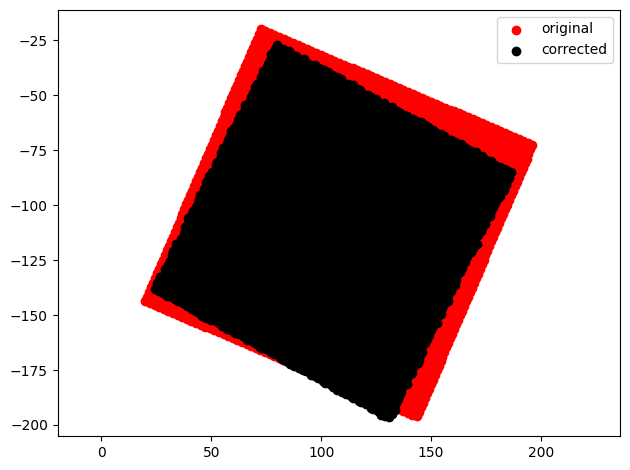

In [ ]:
scan_step = 0.9   # Å
scan_rotation_angle = 23   # degree

# ePIE
run.run_ePIE(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 3,                   # probe states number
        n_slice = 1,                   # object slices number
        slice_thickness = 1,           # object slice thickness in Å
        iter_max = 1500,               # maximum iteration numner
        s_O = 2,                       # step size for updating Object Function
        s_P = 1,                       # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing    
        
        s_position_correction = 1,     # step of position correction
        pc_start_iteration = 500,      # if not setting, position correction will start after 0.25*iter_max
        Obj_pad = 20,                  # pixels, padding the objFunc in case scan positions shift out
        
        POA = True,                    # phase object approximation constraint
        # device = "cuda:0",           # specify the GPU device or use "cpu"
        
        plot_and_save_probe = False,   # set 'True' to plot and save the probe results
        save_results = False,          # set 'True' to save the results
)

It still works! Now, we use LSQML instead of ePIE, reduce the scan step size to 0.8 Å, and use a rotation angle of 33° instead of 28°.


LSQML

File: rawdata_1x_crop

################ Experimental Information ################
Voltage: 80 kV
Alpha: 0.0214 rad
scan step: 0.8 Å/pixel
defocus: 500 Å
scan rotation angle: 33 degrees
scan flip x: False

#################### Data Information ####################
data shape: (60, 60, 124, 124)
data type: float32
CBED intensity range: 0.0 – 12631.6630859375
average CBED intensity: 13356662.0
BF center_Y: 61.8842476094615
BF center_X: 62.277805737292404
BF threshold: 0.5
Aperture Radius: 25.123368670217836 pixels

################ Calculatied Calibration #################
reciprocal space pixel size: 0.020398809585216355 1/Å/pixel
real space pixel size: 0.3953424877732503 Å/pixel
ptycho move: 2.0235619108534624 pixels

############### Probe Mixstates Parameters ###############
Probe States: 3
Probe Generation Mode: Hermite
Probe Radius: 28.442925306655784 pixels

############# Object Multi-slice Parameters ##############
Object Slices: 1
recovered objFunc shape: (1, 330, 330)
Sli

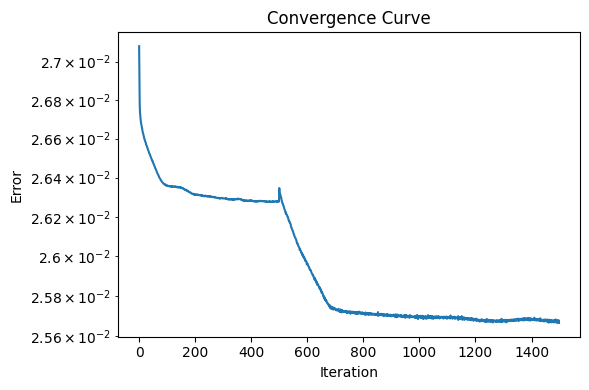

Object saving


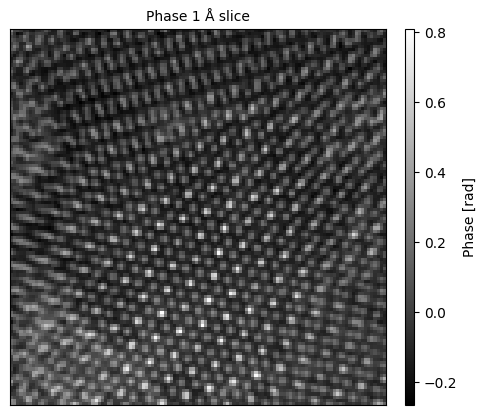

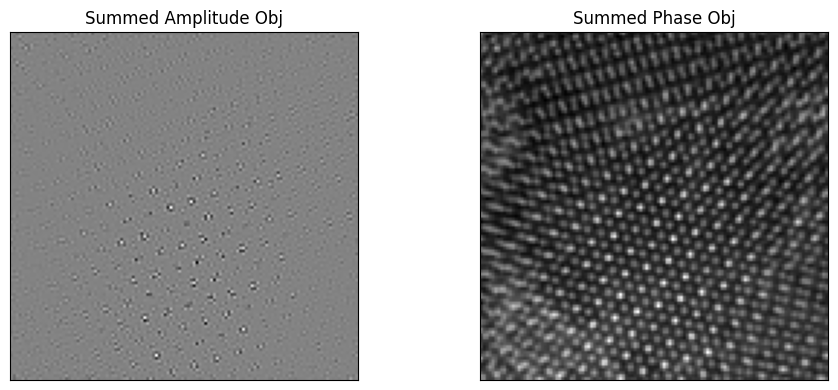

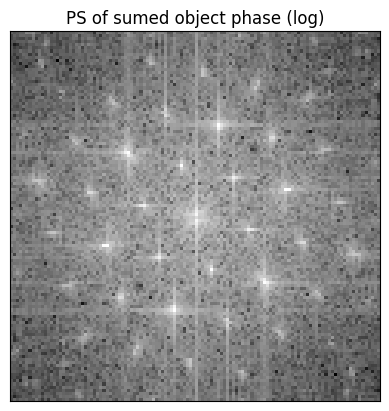

PC saving


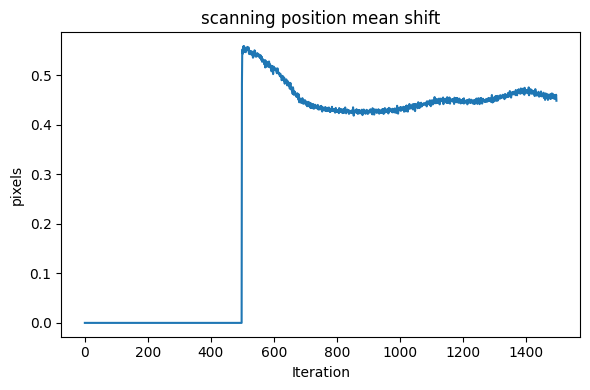

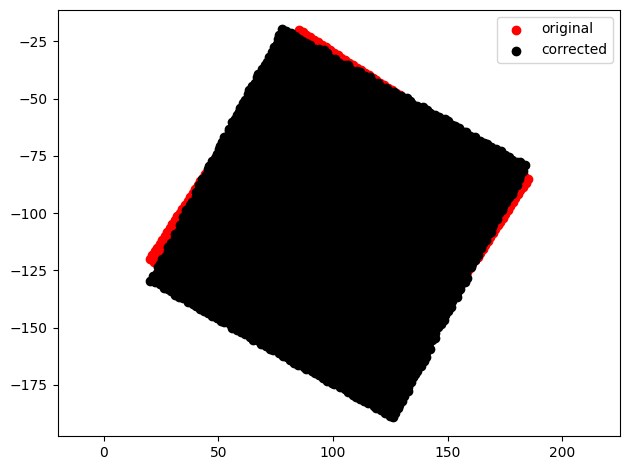

In [ ]:
scan_step = 0.8   # Å
scan_rotation_angle = 33   # degree

# LSQML
run.run_LSQML(file, data_4D, Voltage, alpha, scan_step, scan_rotation_angle, scan_flip, 
        defocus,
        n_state = 3,                   # probe states number
        n_slice = 1,                   # object slices number
        slice_thickness = 1,           # object slice thickness in Å
        iter_max = 1500,               # maximum iteration numner
        s_O = 1,                       # step size for updating Object Function
        s_P = 1,                       # step size for updating Probe Function
        n_block = 60,                  # block number：The CBEDs are divided into n_block blocks for batch computing 
        
        s_position_correction = 1,     # step of position correction
        pc_start_iteration = 500,      # if not setting, position correction will start after 0.25*iter_max
        Obj_pad = 20,                  # pixels, padding the objFunc in case scan positions shift out
        
        POA = True,                    # phase object approximation constraint
        # device = "cuda:0",           # specify the GPU device or use "cpu"

        plot_and_save_probe = False,   # set 'True' to plot and save the probe results
        save_results = False,          # set 'True' to save the results
)

The reconstruction is still quite good. Note that the parameters 's_position_correction', 's_O', and 's_P' need to be carefully chosen to obtain reasonable results.